# CPM Analysis and Network Diagram

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 14, 42, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 5, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 10, 35, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
# df.to_csv('activity_cost_details.csv', index=False)

# Convert durations to days

# df['Crash Duration (Days)'] = df['Crash Duration (Weeks)'] * 7

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [ ]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        # Using info['normal_duration'] instead of 'Normal Duration (Days)'
        G.add_node(act, duration=info['normal_duration'])  
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['EF'] = G.nodes[node]['duration']  
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']  

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']  
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            # Using G.nodes[node]['duration'] to get duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']  

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    print(f'Critical Path: {critical_path}')
    return G, critical_path, project_duration


Generate a cpm_table

In [22]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

G, critical_path, project_duration = calculate_cpm(activities)
def generate_cpm_table(G, critical_path):
    data = []
    for node in G.nodes:
        data.append({
            'Activity': node,
            'Description': activities[node]['name'],
            'Duration': G.nodes[node]['duration'],
            'ES': G.nodes[node]['ES'],
            'EF': G.nodes[node]['EF'],
            'LS': G.nodes[node]['LS'],
            'LF': G.nodes[node]['LF'],
            'Slack': G.nodes[node]['LS'] - G.nodes[node]['ES'],
            'Critical': 'Yes' if node in critical_path else 'No'
        })
    df = pd.DataFrame(data)
    df = df.sort_values(by='ES')  # Optional: sort by start time
    return df


# Generate the table
cpm_table = generate_cpm_table(G, critical_path)

# Save the table to a CSV file
cpm_table.to_csv('cpm_table.csv', index=False)
print('Project Duration: ',project_duration)
# Display the table
print(cpm_table.to_string(index=False))



end_nodes :['C', 'AD']
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']
Project Duration:  445
Activity                          Description  Duration  ES  EF  LS  LF  Slack Critical
       A                      Site Assessment        24   0  24   0  24      0      Yes
       B              Master Plan Development        38  24  62  24  62      0      Yes
       C       Energy/Water Demand Estimation        21  62  83 424 445    362       No
       D                    Feasibility Study        30  62  92  62  92      0      Yes
       J           Solar Panel Site Selection        42  62 104 248 290    186       No
       O         Water Treatment Plant Design        21  92 113 256 277    164       No
       E            Excavation and Earthworks        31  92 123  92 123      0      Yes
       P                  Water Intake System        14 113 127 277 291    164       No
       G          River and Lake Installation        70 123 193 270 340    147    

create a structure of the Network diagram

In [23]:
def compute_layered_positions(G, layer_gap=3.0, node_gap=4.0):
    """
    Compute positions for a directed acyclic graph (DAG) using layered layout.
    Nodes are assigned levels topologically and spaced evenly horizontally within each level.
    """
    # Step 1: Topological sort of nodes
    topo_order = list(nx.topological_sort(G))

    # Step 2: Assign levels based on longest path from source
    level_dict = {}
    for node in topo_order:
        preds = list(G.predecessors(node))
        level_dict[node] = 0 if not preds else max(level_dict[p] + 1 for p in preds)

    # Step 3: Group nodes by level
    levels = {}
    for node, level in level_dict.items():
        levels.setdefault(level, []).append(node)

    # Step 4: Assign positions
    pos = {}
    max_width = max(len(nodes) for nodes in levels.values())

    for level, nodes in levels.items():
        count = len(nodes)
        # Center the nodes at each level
        x_start = -((count - 1) * node_gap) / 2
        for i, node in enumerate(nodes):
            x = x_start + i * node_gap
            y = -level * layer_gap
            pos[node] = (x, y)

    return pos


Draw Network diagram and save it as cpm_diagram.png


C:\Users\Gaurav Nagar\AppData\Local\Temp\ipykernel_17264\2883023609.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Diagram saved as 'cpm_diagram.png'


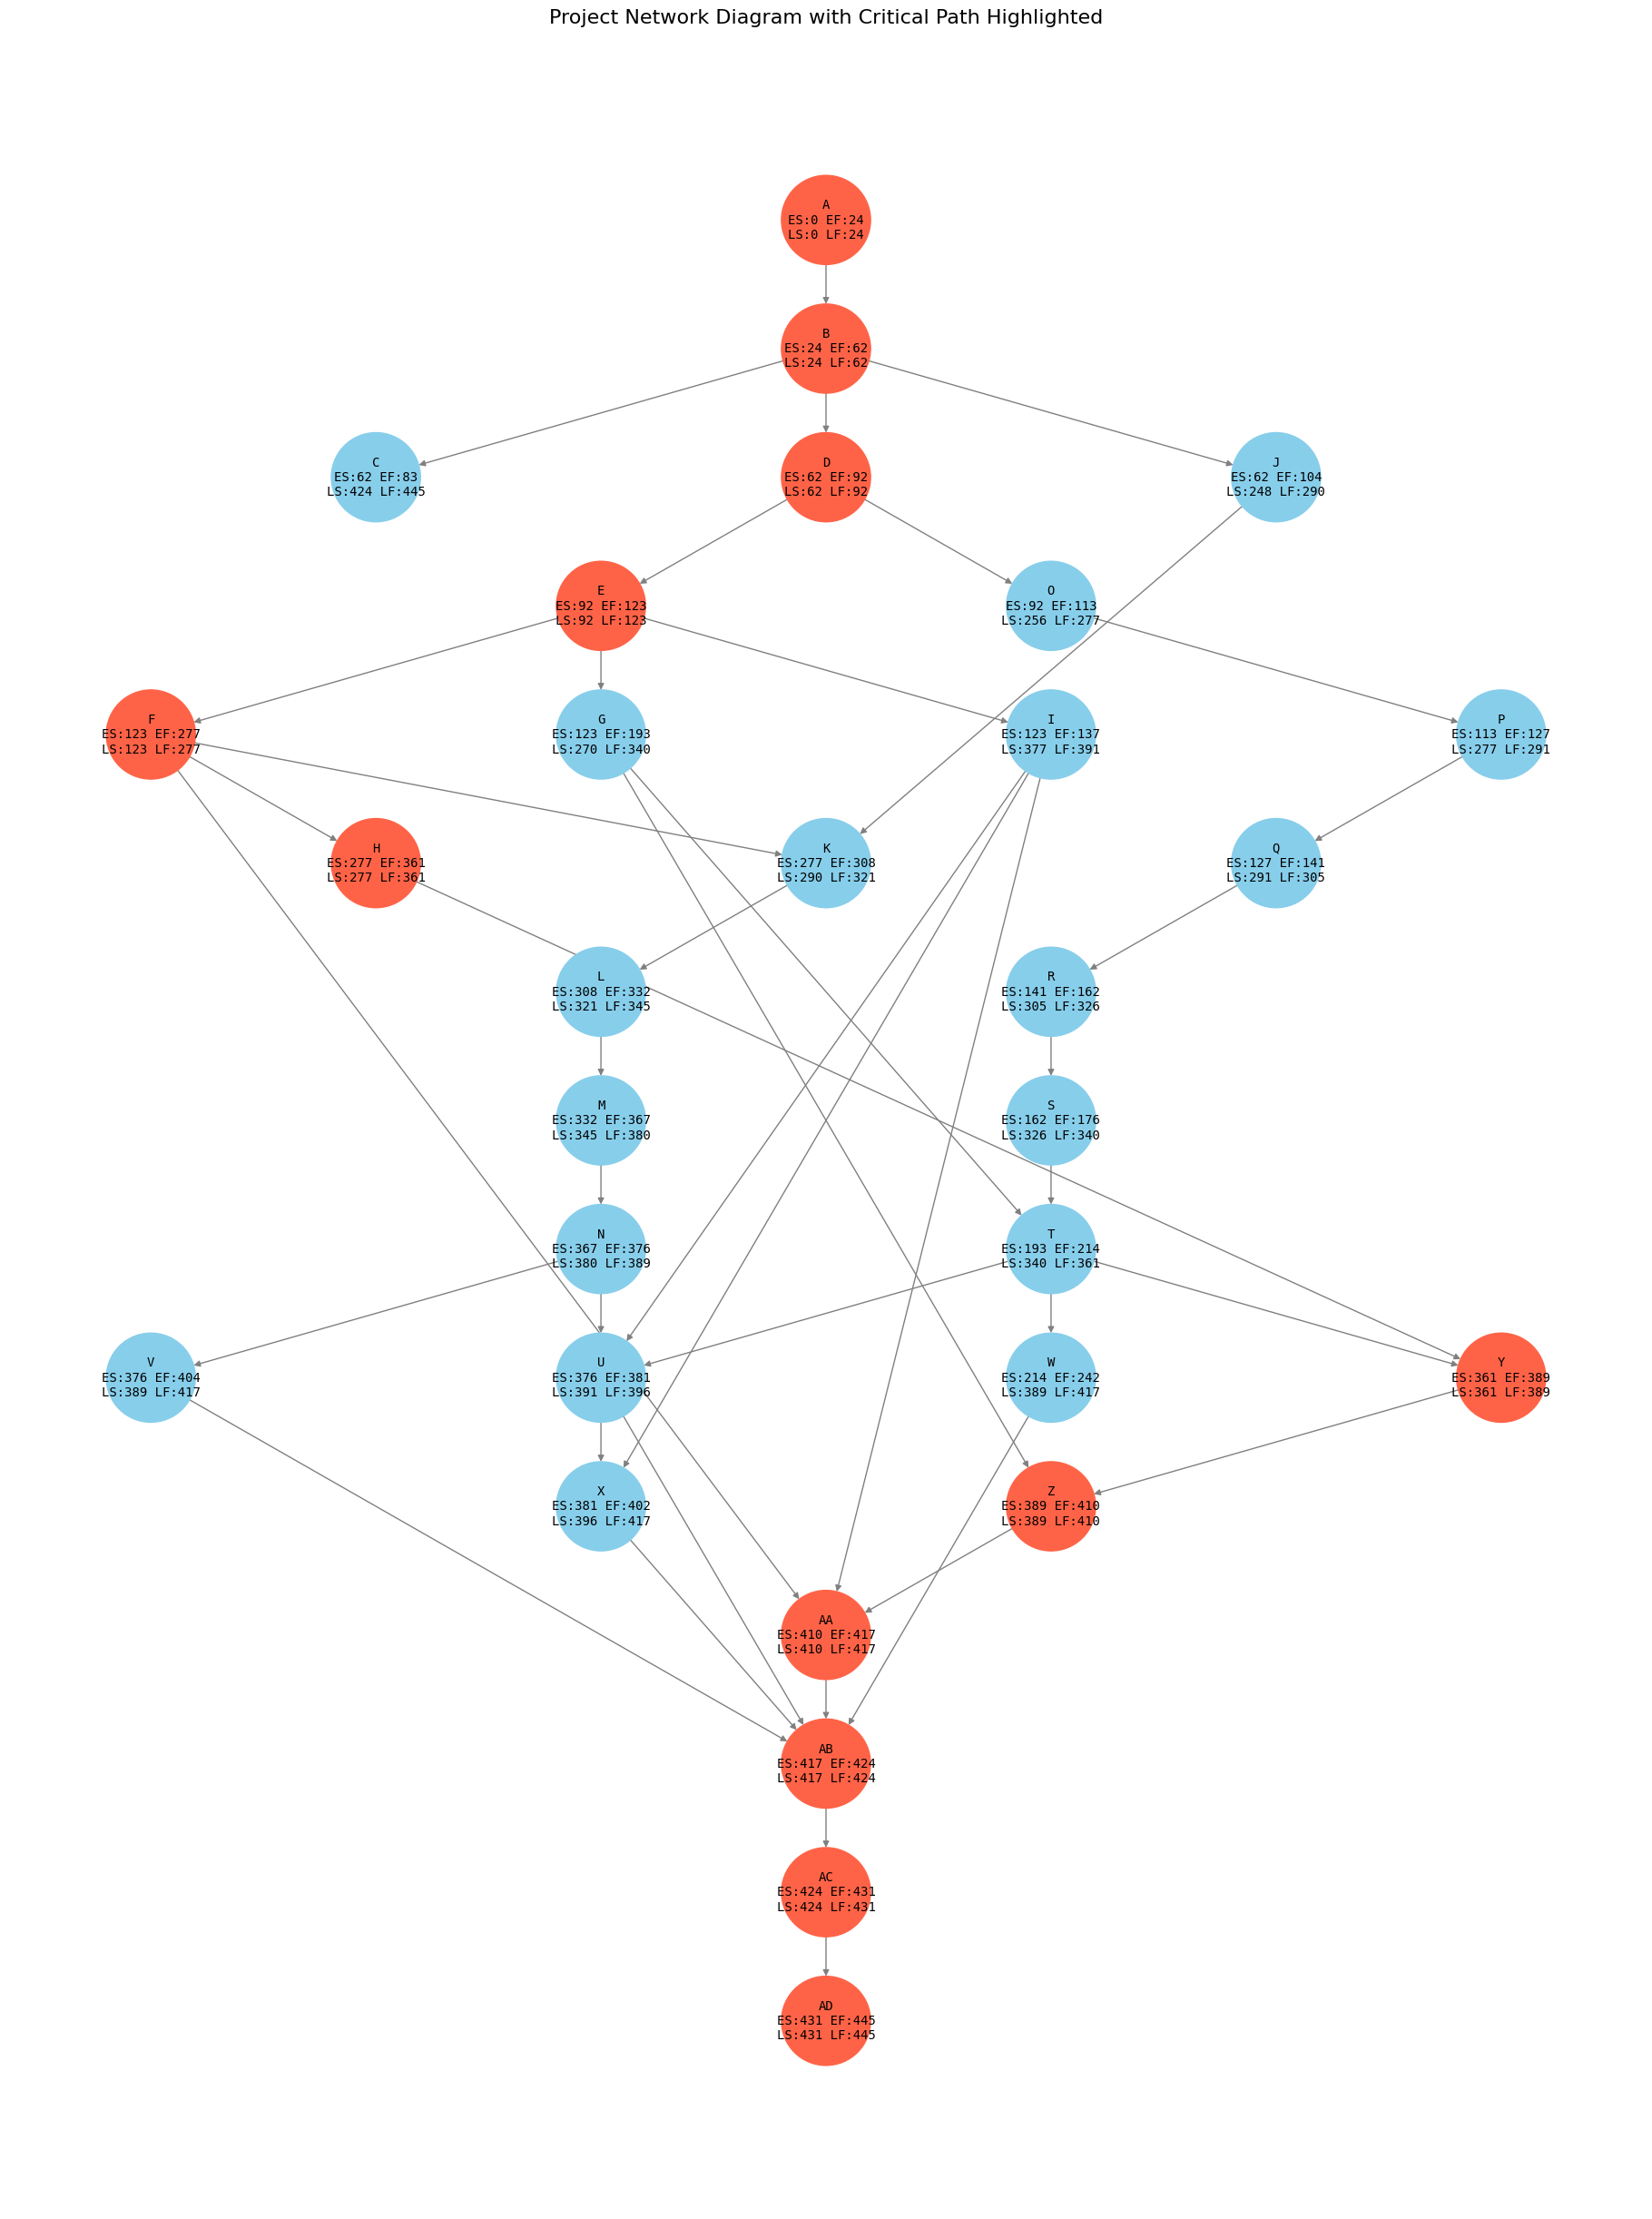

In [24]:
import matplotlib.pyplot as plt

def draw_network_diagram(G, critical_path,filename="network_diagram.png"):
    plt.figure(figsize=(18, 24))
    # pos = nx.spring_layout(G, k=1.2, iterations=100, seed=42)
    pos = compute_layered_positions(G)

    # pos = compute_layered_positions(G, layer_gap=3.0, node_gap=14)

    node_colors = ['tomato' if n in critical_path else 'skyblue' for n in G.nodes]
    labels = {
        n: f"{n}\nES:{G.nodes[n]['ES']} EF:{G.nodes[n]['EF']}\nLS:{G.nodes[n]['LS']} LF:{G.nodes[n]['LF']}"
        for n in G.nodes
    }

    # Draw network
    nx.draw(G, pos, with_labels=False, arrows=True, node_size=5000, node_color=node_colors, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_family="monospace")

    # # Optional: draw edge weights if needed
    # edge_labels = {(u, v): '' for u, v in G.edges}
    # nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=20)

    plt.title("Project Network Diagram with Critical Path Highlighted", fontsize=16)
    plt.axis('off')
    plt.tight_layout()


    plt.savefig(filename, dpi=300)
    print(f"Diagram saved as '{filename}'")

    plt.show()

draw_network_diagram(G, critical_path, filename="cpm_diagram.png")


# ACT_CRASHING

In [26]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 14, 42, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 3, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 10, 35, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
# df.to_csv('activity_cost_details.csv', index=False)

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [27]:
import networkx as nx

# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes :{end_nodes}')

    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} weeks")
print(f"Critical Path: {critical_path}")

Project Duration: 445 weeks
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']


In [28]:
import pandas as pd

def generate_cost_curve(activities, indirect_cost_savings_per_day=142857 / 1000000, penalty_per_day=50000 / 1000000):
    # Calculate initial CPM data
    G, critical_path, normal_duration = calculate_cpm(activities)
    initial_cost = sum(info['normal_cost'] for info in activities.values())
    original_durations = {act: info['normal_duration'] for act, info in activities.items()}

    # Get least possible duration by fully crashing
    for act in activities:
        activities[act]['normal_duration'] = activities[act]['crash_duration']
    _, _, least_duration = calculate_cpm(activities)

    # Restore normal durations
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]

    # Initialize tracking variables
    G, critical_path, current_duration = calculate_cpm(activities)
    duration_history = [normal_duration]
    total_cost_history = [initial_cost]
    current_cost = initial_cost
    days_crashed = 0

    optimum_cost = initial_cost
    optimum_duration = normal_duration
    optimum_critical_activities = []
    optimum_activity_durations = {}
    crashing_order = []
    # Crashing loop
    while current_duration > least_duration:
        crashable = [
            (act, activities[act]['crash_slope'])
            for act in critical_path
            if activities[act]['normal_duration'] > activities[act]['crash_duration']
        ]
        if not crashable:
            break

        act_to_crash = min(crashable, key=lambda x: x[1])[0]
        crashing_order.append(act_to_crash)
        crash_days = min(0.5, activities[act_to_crash]['normal_duration'] - activities[act_to_crash]['crash_duration'])

        crash_cost_increase = crash_days * (activities[act_to_crash]['crash_slope'] / 1_000_000)
        indirect_savings = crash_days * indirect_cost_savings_per_day
        penalty = days_crashed * penalty_per_day if days_crashed > 28 else 0

        current_cost += crash_cost_increase - indirect_savings + penalty

        # Check if this is the lowest cost seen so far
        if current_cost < optimum_cost:
            optimum_cost = current_cost
            optimum_duration = current_duration
            optimum_critical_activities = critical_path[:]
            # Save the durations at this point
            optimum_activity_durations = {
                act: activities[act]['normal_duration'] for act in activities
            }

        # Apply crash
        activities[act_to_crash]['normal_duration'] -= crash_days
        days_crashed += crash_days

        # Recalculate CPM
        G, critical_path, current_duration = calculate_cpm(activities)
        duration_history.append(current_duration)
        total_cost_history.append(current_cost)

    # Optional delay simulation (keeping cost same, increasing duration)
    for act in activities:
        activities[act]['normal_duration'] = original_durations[act]
    G, critical_path, current_duration = calculate_cpm(activities)
    while current_duration < normal_duration:
        current_duration += 1
        total_cost_history.append(current_cost)
        duration_history.append(current_duration)

    print(f"Optimum Duration: {optimum_duration} days")
    print(f"Optimum Cost: ${optimum_cost:.2f}M")
    print(f"Critical Activities at Optimum Cost-Duration: {optimum_critical_activities}")

    # Build crash info DataFrame
    crashed_activities = []
    for act in activities:
        normal = original_durations[act]
        crashed = optimum_activity_durations.get(act, normal)
        if crashed < normal:
            crashed_activities.append({
                'Activity': act,
                'Normal Duration': normal,
                'Crashed Duration': crashed,
                'Days Crashed': normal - crashed
            })

    df_crashed = pd.DataFrame(crashed_activities)

    return duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order


Optimum Duration: 417.0 days
Optimum Cost: $584.31M
Critical Activities at Optimum Cost-Duration: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']
Crashing_order_Details_after_crashing: {'A': 20, 'B': 20, 'AA': 4, 'AD': 4, 'D': 18, 'H': 28, 'V': 14, 'Z': 14, 'X': 7, 'L': 15, 'AB': 2, 'AC': 2, 'Y': 8, 'E': 14, 'F': 28}
Normal Duration: 445 days, Normal Cost: $588.36M
Optimum Duration or Least cost duration: 417.0 days, Optimum Cost: $584.31M
Least Duration: 364 days, Least Cost: $1022.20M


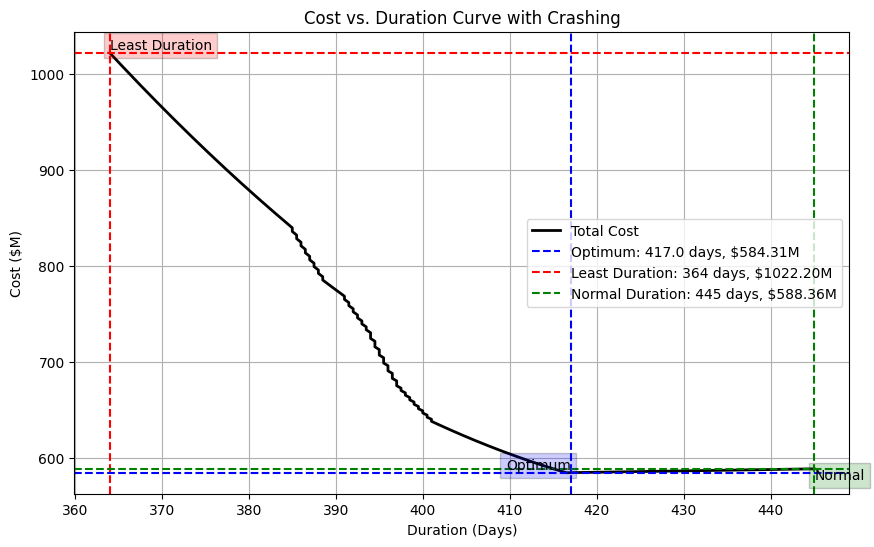

In [29]:
from collections import Counter
# Run curve generation
duration_history, total_cost_history, optimum_duration, optimum_cost, least_duration, initial_cost, normal_duration, df_crashed,crashing_order  = generate_cost_curve(activities) # Added normal_duration to capture the returned value

crashed_dict = Counter(crashing_order)
# Convert counts to crash days
crashed_dict = {act: days for act, days in crashed_dict.items()}
print("Crashing_order_Details_after_crashing:", crashed_dict)


# print("Crashing Order:", crashing_order)  # Print the order
print(f"Normal Duration: {normal_duration} days, Normal Cost: ${initial_cost:.2f}M")
print(f"Optimum Duration or Least cost duration: {optimum_duration} days, Optimum Cost: ${optimum_cost:.2f}M")
print(f"Least Duration: {least_duration} days, Least Cost: ${total_cost_history[duration_history.index(least_duration)]:.2f}M")

# Plot the graph
plt.figure(figsize=(10, 6))
plt.plot(duration_history, total_cost_history, 'k-', label='Total Cost', linewidth=2)
plt.axvline(optimum_duration, color='b', linestyle='--', label=f'Optimum: {optimum_duration} days, ${optimum_cost:.2f}M')
plt.axvline(least_duration, color='r', linestyle='--', label=f'Least Duration: {least_duration} days, ${total_cost_history[duration_history.index(least_duration)]:.2f}M')
plt.axvline(normal_duration, color='g', linestyle='--', label=f'Normal Duration: {normal_duration} days, ${initial_cost:.2f}M')
plt.axhline(optimum_cost, color='b', linestyle='--')
plt.axhline(total_cost_history[duration_history.index(least_duration)], color='r', linestyle='--')
plt.axhline(initial_cost, color='g', linestyle='--')
plt.text(optimum_duration, optimum_cost, 'Optimum', bbox=dict(facecolor='blue', alpha=0.2), ha='right', va='bottom')
plt.text(least_duration, total_cost_history[duration_history.index(least_duration)], 'Least Duration', bbox=dict(facecolor='red', alpha=0.2), ha='left', va='bottom')
plt.text(normal_duration, initial_cost, 'Normal', bbox=dict(facecolor='green', alpha=0.2), ha='left', va='top')
plt.xlabel('Duration (Days)')
plt.ylabel('Cost ($M)')
plt.title('Cost vs. Duration Curve with Crashing')
plt.legend()
plt.grid(True)
plt.show()



# Resource leveling


In [31]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Activity data (same as provided)
data = {
    'Activity ID': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD'],
    'Activity Name': [
        'Site Assessment', 'Master Plan Development', 'Energy/Water Demand Estimation', 'Feasibility Study', 'Excavation and Earthworks', 'Building Construction',
        'River and Lake Installation', 'Vertical Garden Setup', 'Transportation Facility Construction', 'Solar Panel Site Selection', 'Solar Panel Installation',
        'Inverter and Wiring Setup', 'Battery Storage Integration', 'Grid Connection', 'Water Treatment Plant Design', 'Water Intake System', 'Pre-Treatment Installation',
        'Reverse Osmosis System', 'Post-Treatment and Storage', 'Distribution Network', 'System Integration', 'Initial Testing (Energy)', 'Initial Testing (Water)',
        'Transportation Testing', 'Ecosystem Validation', 'Landscaping and Aesthetics', 'Safety and Accessibility', 'Final Inspections', 'Commissioning', 'Maintenance Plan'
    ],
    'Normal Duration (Days)': [24, 38, 21, 30, 31, 154, 70, 84, 14, 42, 31, 24, 35, 9, 21, 14, 14, 21, 14, 21, 3, 28, 28, 21, 28, 21, 7, 7, 7, 14],
    'Crash Duration (Days)': [14, 28, 14, 21, 24, 140, 56, 70, 10, 35, 24, 14, 28, 7, 14, 10, 10, 14, 10, 17, 3, 21, 21, 17, 24, 14, 5, 6, 6, 12],
    'Direct Costs ($M)': [0.02, 0.1, 0.01, 0.08, 0.2, 500, 1.75, 1, 2, 0.01, 5, 0.1, 0.1, 0.05, 0.08, 0.1, 0.1, 0.15, 0.1, 0.15, 0.2, 0.01, 0.01, 0.01, 0.1, 0.15, 0.01, 0.01, 0.01, 0.01],
    'Overhead/Indirect Costs ($M)': [0.003, 0.015, 0.002, 0.012, 0.03, 75, 0.26, 0.15, 0.3, 0.002, 0.75, 0.015, 0.015, 0.0075, 0.012, 0.015, 0.015, 0.0225, 0.015, 0.0225, 0.03, 0.002, 0.002, 0.002, 0.015, 0.0225, 0.002, 0.002, 0.002, 0.002],
    'Normal Cost ($M)': [0.023, 0.115, 0.012, 0.092, 0.23, 575, 2.01, 1.15, 2.3, 0.012, 5.75, 0.115, 0.115, 0.0575, 0.092, 0.115, 0.115, 0.1725, 0.115, 0.1725, 0.23, 0.012, 0.012, 0.012, 0.115, 0.1725, 0.012, 0.012, 0.012, 0.012],
    'Crash Cost ($M)': [0.025, 0.125, 0.014, 0.102, 0.25, 575.2, 2.03, 1.17, 2.32, 0.014, 5.79, 0.125, 0.125, 0.0625, 0.102, 0.125, 0.125, 0.2025, 0.125, 0.1825, 0.25, 0.014, 0.014, 0.014, 0.125, 0.1825, 0.014, 0.014, 0.014, 0.014],
    'Resource Demand (Workers)': [5, 10, 5, 8, 20, 50, 15, 10, 15, 5, 20, 10, 10, 5, 8, 10, 10, 15, 10, 15, 20, 5, 5, 5, 10, 15, 5, 5, 5, 5]
}



# Create activities dictionary with dependencies
dependencies = {
    'A': [], 'B': ['A'], 'C': ['B'], 'D': ['B'], 'E': ['D'], 'F': ['E'], 'G': ['E'], 'H': ['F'], 'I': ['E'], 'J': ['B'],
    'K': ['J', 'F'], 'L': ['K'], 'M': ['L'], 'N': ['M'], 'O': ['D'], 'P': ['O'], 'Q': ['P'], 'R': ['Q'], 'S': ['R'],
    'T': ['S', 'G'], 'U': ['N', 'T', 'I'], 'V': ['N'], 'W': ['T'], 'X': ['I', 'U'], 'Y': ['T', 'H'], 'Z': ['G', 'Y'],
    'AA': ['F', 'I', 'Z'], 'AB': ['U', 'V', 'W', 'X', 'AA'], 'AC': ['AB'], 'AD': ['AC']
}

# Add 'depends' key to each activity in 'data'
for activity_id in data['Activity ID']:
    data_index = data['Activity ID'].index(activity_id)  # Get index of activity in data
    data['depends'] = data.get('depends', []) + [dependencies[activity_id]]
# Create DataFrame and save to CSV
df = pd.DataFrame(data)
df.to_csv('activity_cost_details.csv', index=False)

# Calculate crash slope
df['Crash Slope ($/Day)'] = ((df['Crash Cost ($M)'] - df['Normal Cost ($M)']) / ((df['Normal Duration (Days)'] - df['Crash Duration (Days)'] )) * 1000000).round(2)


activities = {row['Activity ID']: {
    'name': row['Activity Name'],
    'normal_duration': row['Normal Duration (Days)'],
    'crash_duration': row['Crash Duration (Days)'],
    'normal_cost': row['Normal Cost ($M)'],
    'crash_cost': row['Crash Cost ($M)'],
    'depends': dependencies[row['Activity ID']],
    'crash_slope': row['Crash Slope ($/Day)'] if pd.notna(row['Crash Slope ($/Day)']) else float('inf'),
    'resources': row['Resource Demand (Workers)']
} for _, row in df.iterrows()}



In [32]:
# CPM Calculation
def calculate_cpm(activities):
    G = nx.DiGraph()
    for act, info in activities.items():
        G.add_node(act, duration=info['normal_duration'], resources=info['resources'])
        for dep in info['depends']:
            G.add_edge(dep, act)

    # Forward Pass
    for node in nx.topological_sort(G):
        predecessors = list(G.predecessors(node))
        if not predecessors:
            G.nodes[node]['ES'] = 0
            G.nodes[node]['EF'] = G.nodes[node]['duration']
        else:
            G.nodes[node]['ES'] = max(G.nodes[pred]['EF'] for pred in predecessors)
            G.nodes[node]['EF'] = G.nodes[node]['ES'] + G.nodes[node]['duration']

    # Backward Pass
    end_nodes = [n for n, d in G.out_degree() if d == 0]
    # print(f'end_nodes: {end_nodes}')
    project_duration = max(G.nodes[n]['EF'] for n in end_nodes)

    for node in reversed(list(nx.topological_sort(G))):
        successors = list(G.successors(node))
        if not successors:
            G.nodes[node]['LF'] = project_duration
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']
        else:
            G.nodes[node]['LF'] = min(G.nodes[succ]['LS'] for succ in successors)
            G.nodes[node]['LS'] = G.nodes[node]['LF'] - G.nodes[node]['duration']

    # Critical Path
    critical_path = [n for n in G.nodes if G.nodes[n]['ES'] == G.nodes[n]['LS']]
    return G, critical_path, project_duration



Histogram of activties and time

Histogram saved as 'activity_histogram.png'


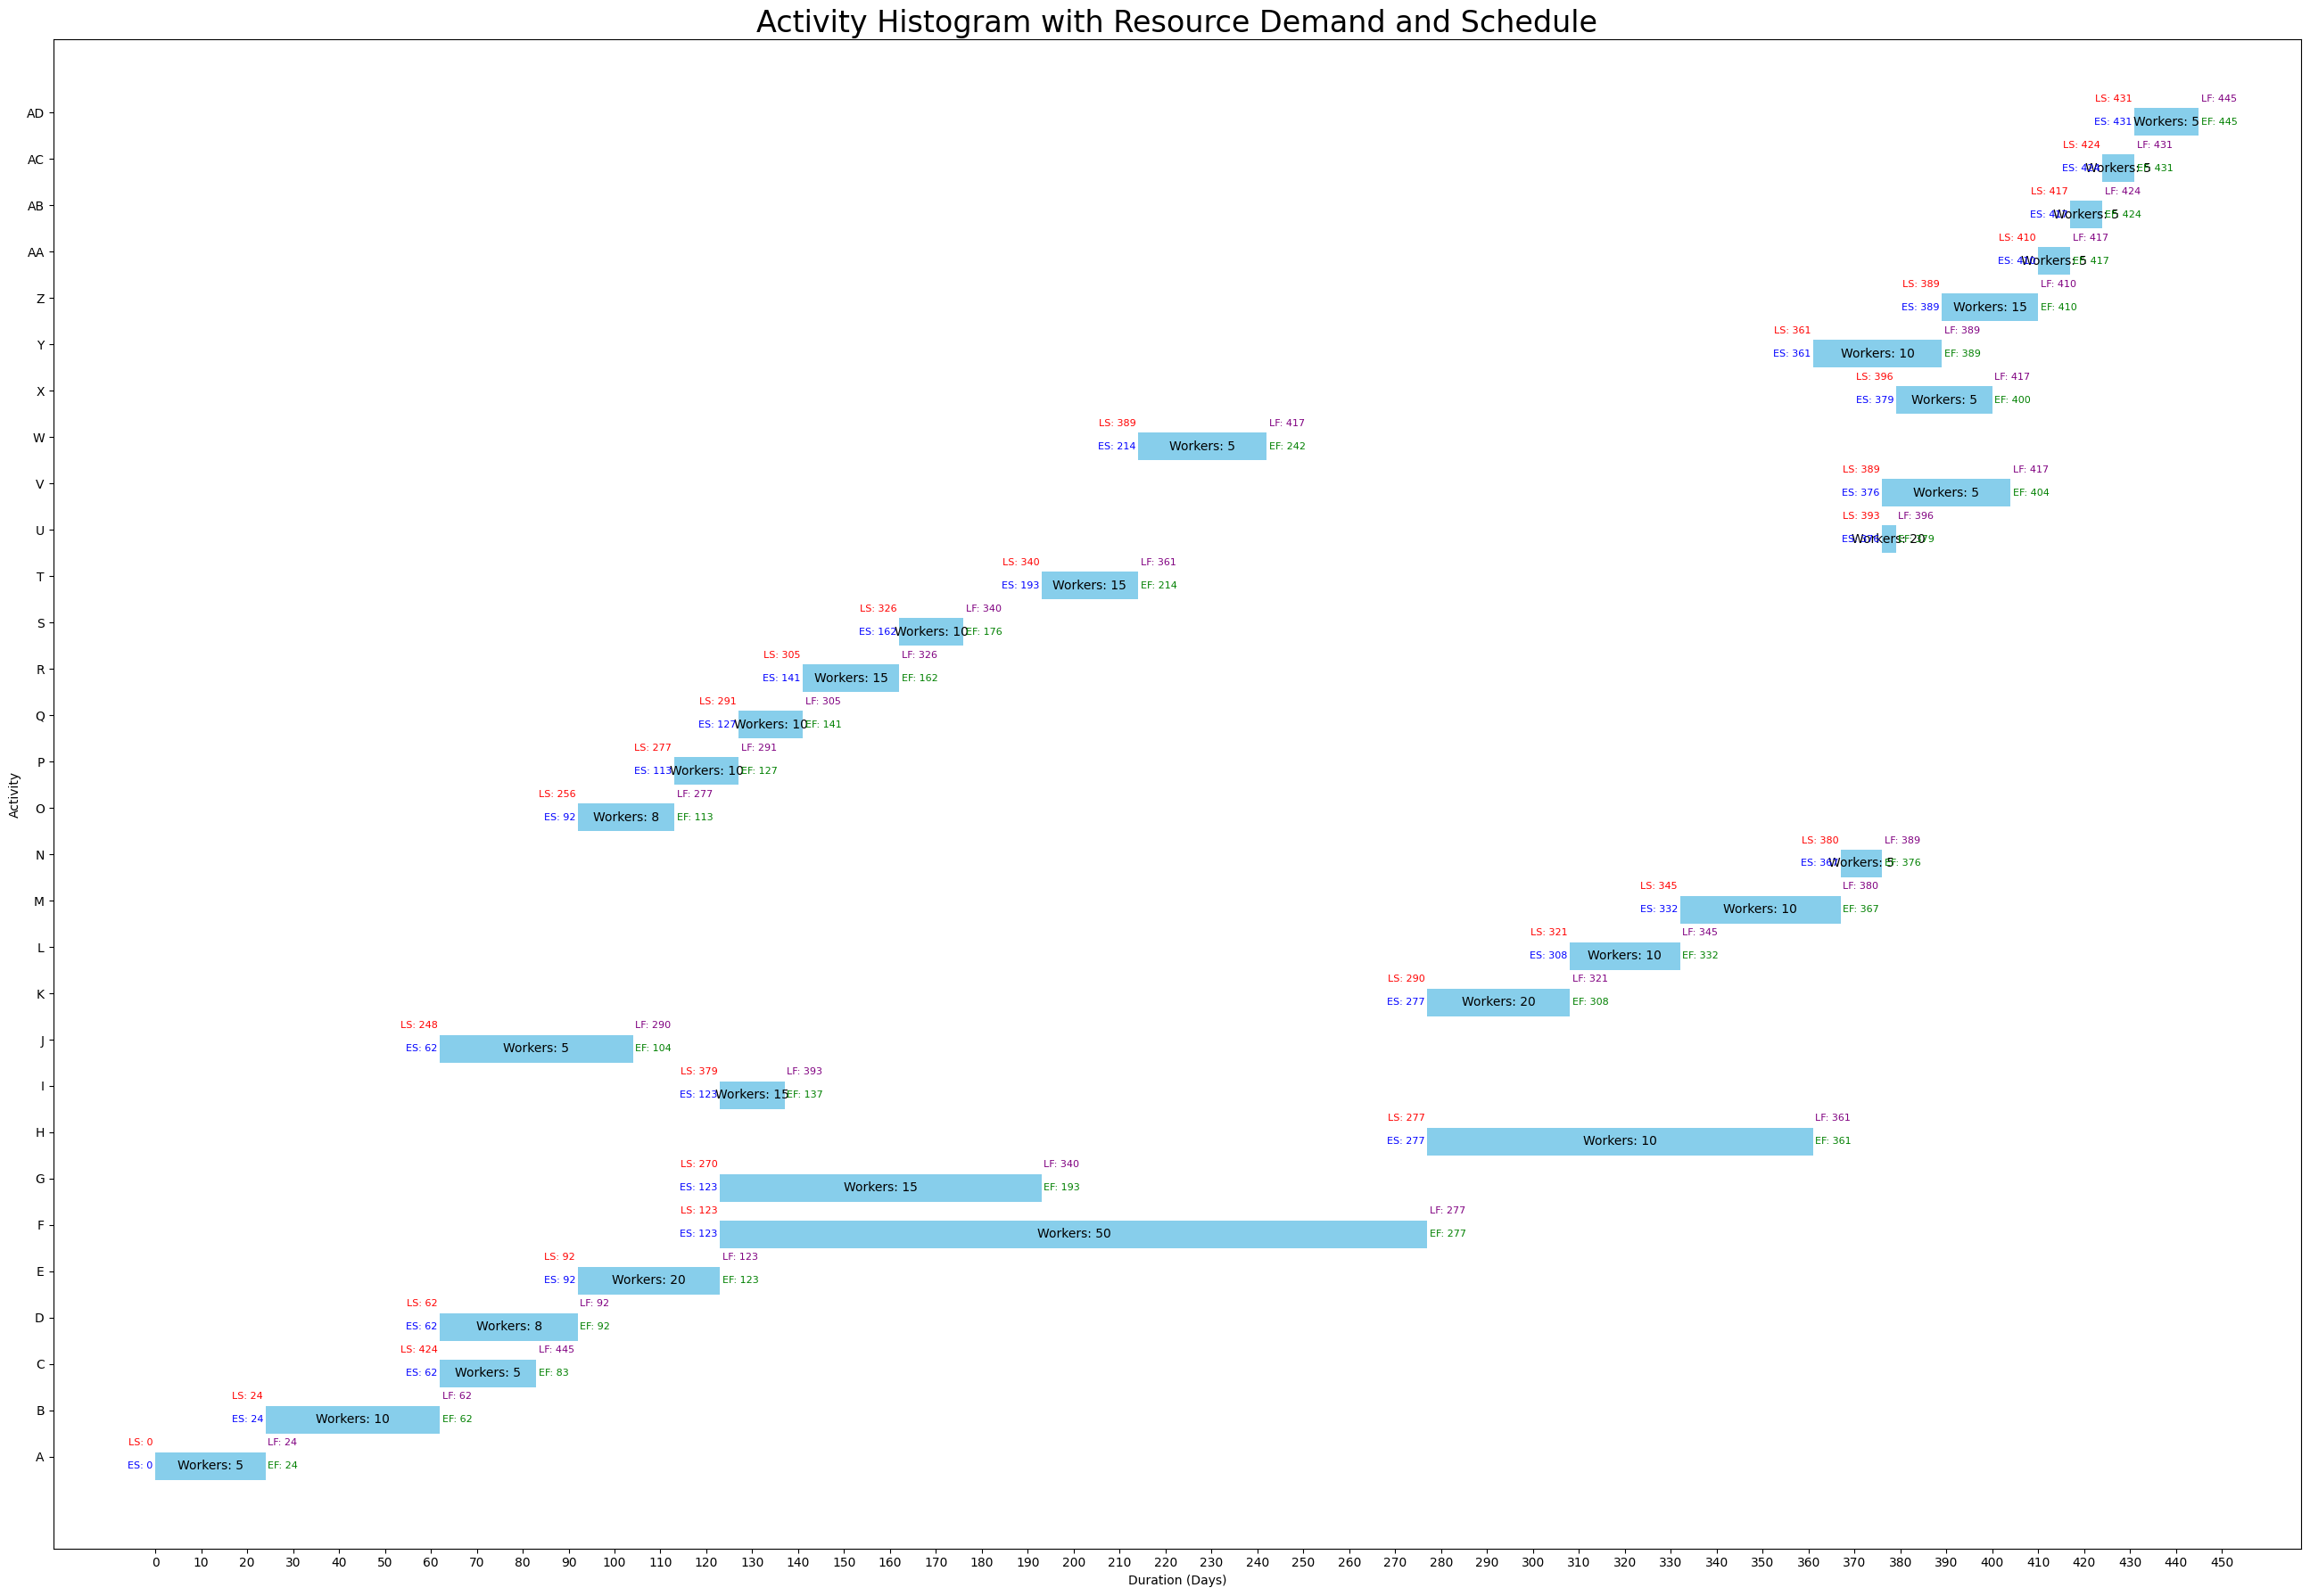

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def plot_activity_histogram(activities, G,filename="activity_histogram.png"):
    # Data for plotting
    activity_names = list(activities.keys())
    durations = [G.nodes[act]['duration'] for act in activity_names]
    es_values = [G.nodes[act]['ES'] for act in activity_names]
    ef_values = [G.nodes[act]['EF'] for act in activity_names]
    ls_values = [G.nodes[act]['LS'] for act in activity_names]
    lf_values = [G.nodes[act]['LF'] for act in activity_names]
    resources = [activities[act]['resources'] for act in activity_names]


    xranges = [[(es, ef - es)] for es, ef in zip(es_values, ef_values)]
    # yrange = [(i * 1, 0.8) for i in range(len(activity_names))] #The original yrange is a list of tuples which caused the issue
    # Modified yrange to a list of tuples with a single tuple for each activity.
    yrange = [(i * 1, 0.6) for i in range(len(activity_names))]

    # Create the histogram
    fig, ax = plt.subplots(figsize=(26, 18))

    # Iterate over xranges and yrange to plot individual bars
    for i in range(len(activity_names)):
        ax.broken_barh(xranges[i], yrange[i], facecolors='skyblue') #Pass each tuple individually to broken_barh


    # Add resource demand as text within bars
    for i, resource in enumerate(resources):
        ax.text(xranges[i][0][0] + xranges[i][0][1] / 2, yrange[i][0] + yrange[i][1] / 2,
                f"Workers: {resource}", ha='center', va='center', color='black')

    # Add ES, EF, LS, LF as text annotations
    for i, (es, ef, ls, lf) in enumerate(zip(es_values, ef_values, ls_values, lf_values)):
        ax.text(es - 0.5, yrange[i][0] + yrange[i][1] / 2, f"ES: {es}", ha='right', va='center', fontsize=8, color='blue')
        ax.text(ef + 0.5, yrange[i][0] + yrange[i][1] / 2, f"EF: {ef}", ha='left', va='center', fontsize=8, color='green')
        ax.text(es - 0.5, yrange[i][0] + yrange[i][1] / 2 + 0.5, f"LS: {ls}", ha='right', va='center', fontsize=8, color='red')
        ax.text(ef + 0.5, yrange[i][0] + yrange[i][1] / 2 + 0.5, f"LF: {lf}", ha='left', va='center', fontsize=8, color='purple')


    max_duration = max(ef_values)
    ax.set_xticks(np.arange(0, max_duration + 10, 10))  # Ticks every 10 days
    ax.set_xlabel("Duration (Days)")

    # Set y-axis ticks and labels
    ax.set_yticks(np.arange(0.5, len(activity_names), 1))  # Centered on bars
    ax.set_yticklabels(activity_names)
    ax.set_ylabel("Activity")
    # Chart formatting

    ax.set_xlabel("Duration (Days)")
    ax.set_ylabel("Activity")
    ax.set_title("Activity Histogram with Resource Demand and Schedule",fontsize=24)
    plt.tight_layout()

    plt.savefig(filename, dpi=300)  # Save the figure
    print(f"Histogram saved as '{filename}'")  # Print confirmation

    plt.show()


G, critical_path, project_duration = calculate_cpm(activities) # Assuming calculate_cpm is defined
plot_activity_histogram(activities, G)



Resource usage before leveling

Project Duration: 445 days
Critical Path: ['A', 'B', 'D', 'E', 'F', 'H', 'Y', 'Z', 'AA', 'AB', 'AC', 'AD']


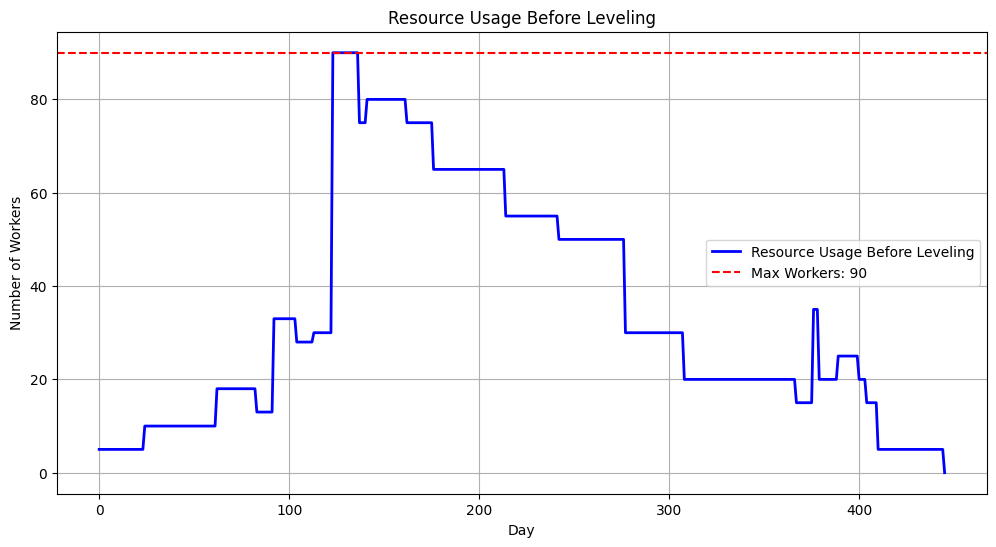

In [34]:
# Calculate resource usage before leveling
def resource_usage_before_leveling(G, activities):
    max_duration = max(G.nodes[n]['EF'] for n in G.nodes)
    resource_profile = [0] * (max_duration + 1)
    for act in activities:
        es = G.nodes[act]['ES']
        ef = G.nodes[act]['EF']
        resources = activities[act]['resources']
        for day in range(es, ef):
            resource_profile[day] += resources
    return resource_profile

# Run CPM and get resource profile before leveling
G, critical_path, project_duration = calculate_cpm(activities)
print(f"Project Duration: {project_duration} days")
print(f"Critical Path: {critical_path}")
resource_profile_before = resource_usage_before_leveling(G, activities)

# Plot resource usage before leveling
plt.figure(figsize=(12, 6))
plt.plot(range(len(resource_profile_before)), resource_profile_before, 'b-', label='Resource Usage Before Leveling', linewidth=2)
plt.axhline(max(resource_profile_before), color='r', linestyle='--', label=f'Max Workers: {max(resource_profile_before)}')
plt.xlabel('Day')
plt.ylabel('Number of Workers')
plt.title('Resource Usage Before Leveling')
plt.legend()
plt.grid(True)
plt.show()

# discussion


New Project Duration: 445 days


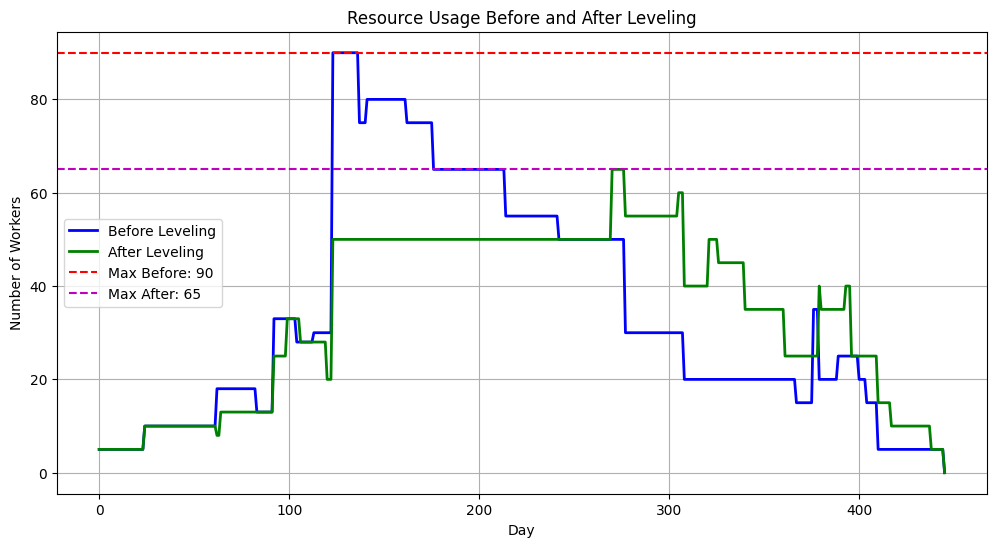

Resource Leveling:
   - Before resource leveling, the maximum resource demand was: 90 workers
   - After resource leveling, the maximum resource demand is reduced to: 65 workers
   - This reduction in peak resource demand was achieved by strategically shifting non-critical activities within their available float (slack).
   - By delaying the start of certain non-critical activities, resource usage was spread out more evenly over time.
   - This prevented the concentration of resource demand at specific periods, which would have required a larger workforce.
   - The leveling process ensured that the project could be completed with a smaller maximum workforce of 60 workers without extending the project duration.
   - This leads to better resource allocation, cost savings, and improved project feasibility.


In [35]:

import numpy as np

# Resource leveling function
def resource_leveling(activities, G, max_resources=60):
    leveled_activities = activities.copy()
    # Calculate float for each activity
    for act in leveled_activities:
        ef = G.nodes[act]['EF']
        lf = G.nodes[act]['LF']
        leveled_activities[act]['float'] = lf - ef

    # Level resources by delaying non-critical activities
    new_G = nx.DiGraph()
    for act, info in leveled_activities.items():
        new_G.add_node(act, duration=info['normal_duration'], resources=info['resources'])
        for dep in info['depends']:
            new_G.add_edge(dep, act)

    # Initial ES and EF
    for node in nx.topological_sort(new_G):
        predecessors = list(new_G.predecessors(node))
        if not predecessors:
            new_G.nodes[node]['ES'] = 0
            new_G.nodes[node]['EF'] = new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['ES'] = max(new_G.nodes[pred]['EF'] for pred in predecessors)
            new_G.nodes[node]['EF'] = new_G.nodes[node]['ES'] + new_G.nodes[node]['duration']

    # Calculate initial LF and LS before adjusting (This is the key fix)
    end_nodes = [n for n, d in new_G.out_degree() if d == 0]
    project_duration = max(new_G.nodes[n]['EF'] for n in end_nodes)
    for node in reversed(list(nx.topological_sort(new_G))):
        successors = list(new_G.successors(node))
        if not successors:
            new_G.nodes[node]['LF'] = project_duration
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['LF'] = min(new_G.nodes[succ]['LS'] for succ in successors)
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']

    # Adjust non-critical activities
    changed = True


# New logic inside the while loop
    while changed:
        changed = False
        resource_profile = resource_usage_before_leveling(new_G, leveled_activities)
        variance_before = np.var(resource_profile)

        # Try delaying non-critical activities with float > 0
        for act in sorted(leveled_activities, key=lambda x: -leveled_activities[x]['float']):  # Higher float first
            if leveled_activities[act]['float'] > 0:
                current_es = new_G.nodes[act]['ES']
                max_delay = leveled_activities[act]['float']
                best_es = current_es
                best_variance = variance_before

                for delay in range(1, max_delay + 1):
                    trial_es = current_es + delay
                    if trial_es > new_G.nodes[act]['LF'] - new_G.nodes[act]['duration']:
                        continue

                    # Temporarily shift activity
                    temp_G = new_G.copy()
                    temp_G.nodes[act]['ES'] = trial_es
                    temp_G.nodes[act]['EF'] = trial_es + temp_G.nodes[act]['duration']

                    # Shift successors
                    for succ in nx.descendants(temp_G, act):
                        preds = list(temp_G.predecessors(succ))
                        temp_G.nodes[succ]['ES'] = max(temp_G.nodes[p]['EF'] for p in preds)
                        temp_G.nodes[succ]['EF'] = temp_G.nodes[succ]['ES'] + temp_G.nodes[succ]['duration']

                    # Recalculate resource profile
                    temp_profile = resource_usage_after_leveling(temp_G, leveled_activities)
                    temp_variance = np.var(temp_profile)

                    if temp_variance < best_variance:
                        best_es = trial_es
                        best_variance = temp_variance
                        changed = True

                if best_es != current_es:
                    new_G.nodes[act]['ES'] = best_es
                    new_G.nodes[act]['EF'] = best_es + new_G.nodes[act]['duration']
                    for succ in nx.descendants(new_G, act):
                        preds = list(new_G.predecessors(succ))
                        new_G.nodes[succ]['ES'] = max(new_G.nodes[p]['EF'] for p in preds)
                        new_G.nodes[succ]['EF'] = new_G.nodes[succ]['ES'] + new_G.nodes[succ]['duration']

        if not changed:
            break


    # Recalculate backward pass to ensure feasibility
    end_nodes = [n for n, d in new_G.out_degree() if d == 0]
    project_duration = max(new_G.nodes[n]['EF'] for n in end_nodes)
    for node in reversed(list(nx.topological_sort(new_G))):
        successors = list(new_G.successors(node))
        if not successors:
            new_G.nodes[node]['LF'] = project_duration
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']
        else:
            new_G.nodes[node]['LF'] = min(new_G.nodes[succ]['LS'] for succ in successors)
            new_G.nodes[node]['LS'] = new_G.nodes[node]['LF'] - new_G.nodes[node]['duration']

    return new_G, project_duration

# Calculate resource usage after leveling
def resource_usage_after_leveling(new_G, activities):
    max_duration = max(new_G.nodes[n]['EF'] for n in new_G.nodes)
    resource_profile = [0] * (max_duration + 1)
    for act in activities:
        es = new_G.nodes[act]['ES']
        ef = new_G.nodes[act]['EF']
        resources = activities[act]['resources']
        for day in range(es, ef):
            resource_profile[day] += resources
    return resource_profile

# Perform leveling and get new profiles
new_G, new_project_duration = resource_leveling(activities, G)
resource_profile_after = resource_usage_after_leveling(new_G, activities)
print(f"New Project Duration: {new_project_duration} days")

# Plot both resource usages
plt.figure(figsize=(12, 6))
plt.plot(range(len(resource_profile_before)), resource_profile_before, 'b-', label='Before Leveling', linewidth=2)
plt.plot(range(len(resource_profile_after)), resource_profile_after, 'g-', label='After Leveling', linewidth=2)
plt.axhline(max(resource_profile_before), color='r', linestyle='--', label=f'Max Before: {max(resource_profile_before)}')
plt.axhline(max(resource_profile_after), color='m', linestyle='--', label=f'Max After: {max(resource_profile_after)}')
plt.xlabel('Day')
plt.ylabel('Number of Workers')
plt.title('Resource Usage Before and After Leveling')
plt.legend()
plt.grid(True)
plt.show()

#  Resource Leveling:
print("Resource Leveling:")
print(f"   - Before resource leveling, the maximum resource demand was: {max(resource_profile_before)} workers")
print(f"   - After resource leveling, the maximum resource demand is reduced to: {max(resource_profile_after)} workers")
print("   - This reduction in peak resource demand was achieved by strategically shifting non-critical activities within their available float (slack).")
print("   - By delaying the start of certain non-critical activities, resource usage was spread out more evenly over time.")
print("   - This prevented the concentration of resource demand at specific periods, which would have required a larger workforce.")
print("   - The leveling process ensured that the project could be completed with a smaller maximum workforce of 60 workers without extending the project duration.")
print("   - This leads to better resource allocation, cost savings, and improved project feasibility.")

# PROGRESS UPDATES AND EARNED VALUE ANALYSIS

In [36]:
import pandas as pd
from datetime import datetime, timedelta

import matplotlib.pyplot as plt


def generate_progress_update(update_date, completed_activities, activity_df):
    """Generates a progress update DataFrame.

    Args:
        update_date: Date of the progress update (string, e.g., '2024-03-15').
        completed_activities: List of activity IDs that have been completed.
        activity_df: DataFrame with activity details.

    Returns:
        DataFrame with updated progress information.
    """
    progress_df = activity_df.copy()
    progress_df['Status'] = 'In Progress'
    progress_df['Update Date'] = update_date

    for activity_id in completed_activities:
        progress_df.loc[progress_df['Activity ID'] == activity_id, 'Status'] = 'Completed'

    return progress_df

def calculate_eva(progress_df, update_date, project_start_date, actual_costs=None):
    """Calculates Earned Value Analysis metrics.

    Args:
        progress_df: DataFrame with progress update data.
        update_date: Date of the progress update (string, e.g., '2024-03-15').
        project_start_date: Project start date (string, e.g., '2024-03-01').
        actual_costs: Dictionary of actual costs {Activity ID: cost in $M}.

    Returns:
        Dictionary with EVA metrics.
    """
    update_date = pd.to_datetime(update_date)
    pv, ev, ac = 0, 0, 0

    for _, row in progress_df.iterrows():
        planned_cost = row['Normal Cost ($M)']
        es = row['early_start']
        ef = row['early_finish']
        duration_days = row['duration_days']
        status = row['Status']
        activity_id = row['Activity ID']

        # Calculate PV
        if pd.isna(es) or pd.isna(ef):
            planned_progress = 0
        elif update_date < es:
            planned_progress = 0
        elif update_date >= ef:
            planned_progress = 1
        else:
            days_progressed = (update_date - es).days
            planned_progress = days_progressed / duration_days if duration_days > 0 else 0

        pv += planned_cost * planned_progress

        # Calculate EV
        if status == 'Completed':
            ev += planned_cost

        # Calculate AC
        if actual_costs and activity_id in actual_costs and status == 'Completed':
            ac += actual_costs[activity_id]

    # Derived metrics
    cv = ev - ac
    sv = ev - pv
    cpi = ev / ac if ac > 0 else float('inf')
    spi = ev / pv if pv > 0 else float('inf')

    return {
        'Planned Value (PV)': pv,
        'Earned Value (EV)': ev,
        'Actual Cost (AC)': ac,
        'Cost Variance (CV)': cv,
        'Schedule Variance (SV)': sv,
        'Cost Performance Index (CPI)': cpi,
        'Schedule Performance Index (SPI)': spi
    }

def plot_eva_metrics(eva_history):
    """Plots EVA metrics over time.

    Args:
        eva_history: Dictionary where keys are update dates and values are EVA metric dictionaries.
    """
    dates = list(eva_history.keys())
    pv_values = [eva['Planned Value (PV)'] for eva in eva_history.values()]
    ev_values = [eva['Earned Value (EV)'] for eva in eva_history.values()]
    ac_values = [eva['Actual Cost (AC)'] for eva in eva_history.values()]

    plt.figure(figsize=(12, 6))
    plt.plot(dates, pv_values, label='Planned Value (PV)', marker='o')
    plt.plot(dates, ev_values, label='Earned Value (EV)', marker='o')
    plt.plot(dates, ac_values, label='Actual Cost (AC)', marker='o')
    plt.title('Earned Value Analysis Over Time')
    plt.xlabel('Update Date')
    plt.ylabel('Cost ($M)')
    plt.grid(True)
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()





Progress Update 1 (March 15, 2024):
   Activity ID                         Activity Name       Status Update Date
0            A                       Site Assessment    Completed  2024-02-25
1            B               Master Plan Development    Completed  2024-02-25
2            C        Energy/Water Demand Estimation    Completed  2024-02-25
3            D                     Feasibility Study  In Progress  2024-02-25
4            E             Excavation and Earthworks  In Progress  2024-02-25
5            F                 Building Construction  In Progress  2024-02-25
6            G           River and Lake Installation  In Progress  2024-02-25
7            H                 Vertical Garden Setup  In Progress  2024-02-25
8            I  Transportation Facility Construction  In Progress  2024-02-25
9            J            Solar Panel Site Selection  In Progress  2024-02-25
10           K              Solar Panel Installation  In Progress  2024-02-25
11           L             

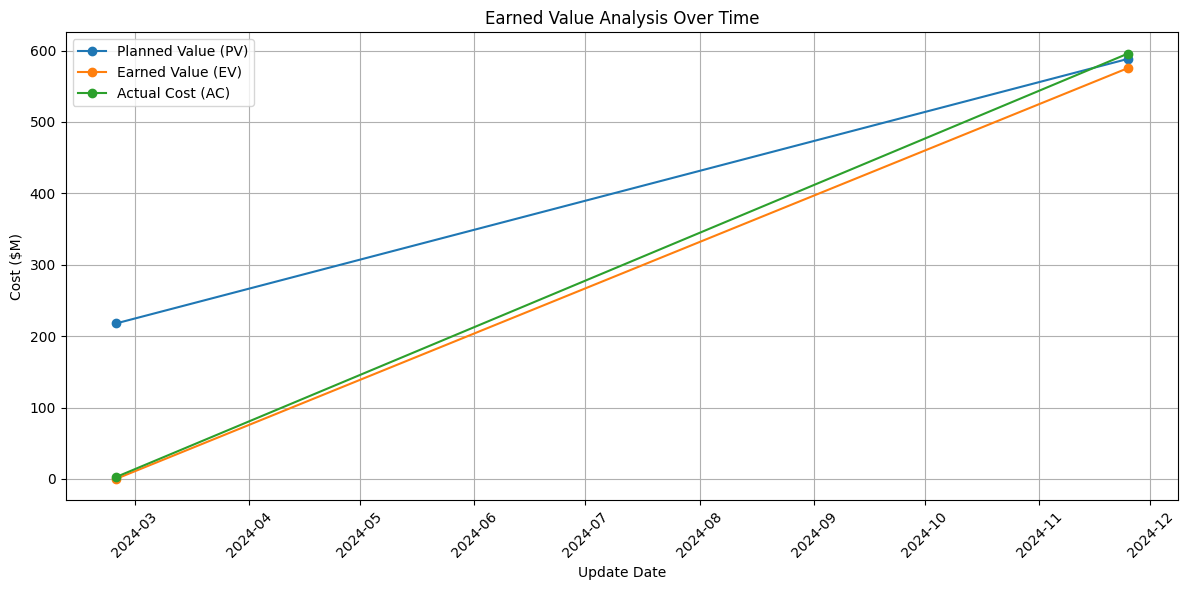

In [41]:

# Load activity data
try:
    activity_df = pd.read_csv("activity_cost_detail.csv")
except FileNotFoundError:
    print("Error: activity_cost_details.csv not found. Using sample data.")
   

# Prepare data
activity_df['duration_days'] = activity_df['Normal Duration (Days)']

# Build schedule
project_start_date = pd.to_datetime('2024-01-01')
activity_df['early_start'] = pd.NaT
activity_df['early_finish'] = pd.NaT

for idx, row in activity_df.iterrows():
    depends = row['depends'].split(',') if row['depends'] else []

    if not depends:
        activity_df.loc[idx, 'early_start'] = project_start_date
    else:
        pred_efs = []
        for pred in depends:
            if pred in activity_df['Activity ID'].values:
                pred_ef = activity_df.loc[activity_df['Activity ID'] == pred, 'early_finish'].iloc[0]
                if pd.notna(pred_ef):
                    pred_efs.append(pred_ef)
        if pred_efs:
            activity_df.loc[idx, 'early_start'] = max(pred_efs)
        else:
            activity_df.loc[idx, 'early_start'] = project_start_date

    if pd.notna(activity_df.loc[idx, 'early_start']):
        activity_df.loc[idx, 'early_finish'] = activity_df.loc[idx, 'early_start'] + timedelta(days=row['duration_days'])

# Generate progress updates
update_date1 = '2024-02-25'
completed_activities1 = ['A', 'B', 'C']
progress_update1 = generate_progress_update(update_date1, completed_activities1, activity_df)

update_date2 = '2024-11-25'
completed_activities2 = ['A', 'B', 'C', 'D', 'E', 'F']
progress_update2 = generate_progress_update(update_date2, completed_activities2, activity_df)

# Hypothetical actual costs (replace with real data)
actual_costs1 = {'A': 0.85, 'B': 0.85, 'C': 1.05}  # In $M
actual_costs2 = {
    'A': 0.85, 'B': 0.85, 'C': 1.05, 'D': 1.50, 'E': 1.55, 'F': 590
    
}

# Calculate EVA for each update
eva_metrics1 = calculate_eva(progress_update1, update_date1, project_start_date, actual_costs1)
eva_metrics2 = calculate_eva(progress_update2, update_date2, project_start_date, actual_costs2)

# Store EVA history for plotting
eva_history = {
    pd.to_datetime(update_date1): eva_metrics1,
    pd.to_datetime(update_date2): eva_metrics2
}

# Display results
print("\nProgress Update 1 (March 15, 2024):")
print(progress_update1[['Activity ID', 'Activity Name', 'Status', 'Update Date']])
print("\nEVA Metrics for Update 1:")
for key, value in eva_metrics1.items():
    print(f"{key}: {value:.2f}")

print("\nProgress Update 2 (April 30, 2024):")
print(progress_update2[['Activity ID', 'Activity Name', 'Status', 'Update Date']])
print("\nEVA Metrics for Update 2:")
for key, value in eva_metrics2.items():
    print(f"{key}: {value:.2f}")

# Generate and display EVA graphs
plot_eva_metrics(eva_history)

# Save progress updates
progress_update1.to_csv('progress_update1.csv', index=False)
progress_update2.to_csv('progress_update2.csv', index=False)

In [42]:
def reschedule_activities(progress_df, current_date, activity_df, max_workers=20):
    """Reschedules incomplete activities based on progress and resource constraints.

    Args:
        progress_df: DataFrame with current progress (from generate_progress_update).
        current_date: Date to start rescheduling (string, e.g., '2024-03-15').
        activity_df: DataFrame with activity details.
        max_workers: Maximum available workers to avoid overallocation.

    Returns:
        DataFrame with updated early_start and early_finish for all activities.
    """
    current_date = pd.to_datetime(current_date)
    rescheduled_df = activity_df.copy()
    rescheduled_df['early_start'] = pd.NaT
    rescheduled_df['early_finish'] = pd.NaT

    # Lock completed activities
    for _, row in progress_df.iterrows():
        if row['Status'] == 'Completed':
            activity_id = row['Activity ID']
            # Assume completion at update date (simplify; replace with actual if available)
            rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_finish'] = pd.to_datetime(row['Update Date'])
            rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_start'] = rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_finish'] - timedelta(days=row['duration_days'])

    # Schedule incomplete activities
    incomplete_activities = rescheduled_df[progress_df['Status'] != 'Completed']['Activity ID'].tolist()
    
    for activity_id in incomplete_activities:
        row = rescheduled_df[rescheduled_df['Activity ID'] == activity_id].iloc[0]
        depends = row['depends'].split(',') if row['depends'] else []
        duration_days = row['duration_days']
        duration_days = int(duration_days)


        # Calculate ES
        if not depends:
            es = max(current_date, pd.to_datetime('2024-03-01'))  # Project start or current date
        else:
            pred_efs = []
            for pred in depends:
                if pred in rescheduled_df['Activity ID'].values:
                    pred_ef = rescheduled_df.loc[rescheduled_df['Activity ID'] == pred, 'early_finish'].iloc[0]
                    if pd.notna(pred_ef):
                        pred_efs.append(pred_ef)
            es = max(pred_efs) if pred_efs else current_date

        # Adjust ES for resource constraints
        while True:
            ef = es + timedelta(days=duration_days)
            # Check resource demand for overlapping activities
            overlapping_workers = 0
            for _, other_row in rescheduled_df.iterrows():
                if pd.isna(other_row['early_start']) or pd.isna(other_row['early_finish']):
                    continue
                if (other_row['early_start'] <= ef) and (other_row['early_finish'] >= es):
                    overlapping_workers += other_row['Resource Demand (Workers)']
            
            if overlapping_workers <= max_workers:
                break
            es += timedelta(days=1)  # Delay by 1 day and retry

        rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_start'] = es
        rescheduled_df.loc[rescheduled_df['Activity ID'] == activity_id, 'early_finish'] = ef

    return rescheduled_df

# Load activity data
try:
    activity_df = pd.read_csv("activity_cost_detail.csv")
except FileNotFoundError:
    print("Error: activity_cost_detail.csv not found. Using sample data.")
   

# Prepare data
activity_df['duration_days'] = activity_df['Normal Duration (Days)']

# Build initial schedule
project_start_date = pd.to_datetime('2024-03-01')
activity_df['early_start'] = pd.NaT
activity_df['early_finish'] = pd.NaT

for idx, row in activity_df.iterrows():
    depends = row['depends'].split(',') if row['depends'] else []
    
    if not depends:
        activity_df.loc[idx, 'early_start'] = project_start_date
    else:
        pred_efs = []
        for pred in depends:
            if pred in activity_df['Activity ID'].values:
                pred_ef = activity_df.loc[activity_df['Activity ID'] == pred, 'early_finish'].iloc[0]
                if pd.notna(pred_ef):
                    pred_efs.append(pred_ef)
        if pred_efs:
            activity_df.loc[idx, 'early_start'] = max(pred_efs)
        else:
            activity_df.loc[idx, 'early_start'] = project_start_date
    
    if pd.notna(activity_df.loc[idx, 'early_start']):
        activity_df.loc[idx, 'early_finish'] = activity_df.loc[idx, 'early_start'] + timedelta(days=row['duration_days'])

# Generate progress updates
update_date1 = '2024-03-15'
completed_activities1 = ['A', 'B', 'C', 'D']
progress_update1 = generate_progress_update(update_date1, completed_activities1, activity_df)

update_date2 = '2024-04-30'
completed_activities2 = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
progress_update2 = generate_progress_update(update_date2, completed_activities2, activity_df)

# Reschedule after progress_update1
rescheduled_df = reschedule_activities(progress_update1, update_date1, activity_df, max_workers=20)

# Calculate EVA with rescheduled plan
actual_costs1 = {'A': 0.55, 'B': 0.85, 'C': 1.05, 'D': 1.35}
actual_costs2 = {
    'A': 0.55, 'B': 0.85, 'C': 1.05, 'D': 1.35, 'E': 1.55, 'F': 1.05,
    'G': 0.75, 'H': 0.52, 'I': 0.22, 'J': 0.32, 'K': 0.65
}

# Update progress_update1 with rescheduled dates
progress_update1_rescheduled = progress_update1.drop(['early_start', 'early_finish'], axis=1)
progress_update1_rescheduled = progress_update1_rescheduled.merge(
    rescheduled_df[['Activity ID', 'early_start', 'early_finish']],
    on='Activity ID',
    how='left'
)

eva_metrics1 = calculate_eva(progress_update1_rescheduled, update_date1, project_start_date, actual_costs1)
eva_metrics2 = calculate_eva(progress_update2, update_date2, project_start_date, actual_costs2)

# Display results
print("\nProgress Update 1 (March 15, 2024):")
print(progress_update1[['Activity ID', 'Activity Name', 'Status', 'Update Date']])
print("\nRescheduled Plan:")
print(rescheduled_df[['Activity ID', 'Activity Name', 'early_start', 'early_finish', 'Resource Demand (Workers)']])
print("\nEVA Metrics for Update 1 (Rescheduled):")
for key, value in eva_metrics1.items():
    print(f"{key}: {value:.2f}")

print("\nProgress Update 2 (April 30, 2024):")
print(progress_update2[['Activity ID', 'Activity Name', 'Status', 'Update Date']])
print("\nEVA Metrics for Update 2:")
for key, value in eva_metrics2.items():
    print(f"{key}: {value:.2f}")

# Save outputs
progress_update1_rescheduled.to_csv('progress_update1_rescheduled.csv', index=False)
progress_update2.to_csv('progress_update2.csv', index=False)
rescheduled_df.to_csv('rescheduled_plan.csv', index=False)


Progress Update 1 (March 15, 2024):
   Activity ID                         Activity Name       Status Update Date
0            A                       Site Assessment    Completed  2024-03-15
1            B               Master Plan Development    Completed  2024-03-15
2            C        Energy/Water Demand Estimation    Completed  2024-03-15
3            D                     Feasibility Study    Completed  2024-03-15
4            E             Excavation and Earthworks  In Progress  2024-03-15
5            F                 Building Construction  In Progress  2024-03-15
6            G           River and Lake Installation  In Progress  2024-03-15
7            H                 Vertical Garden Setup  In Progress  2024-03-15
8            I  Transportation Facility Construction  In Progress  2024-03-15
9            J            Solar Panel Site Selection  In Progress  2024-03-15
10           K              Solar Panel Installation  In Progress  2024-03-15
11           L             